In [35]:
pip install plip

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ------------------------------ --------- 4.2/5.5 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 25.7 MB/s  0:00:00
  Created wheel for plip: filename=plip-3.0.0-py3-none-any.whl size=87095 sha256=ddc9f16f7d8085a23dbca62972dc9882e41ee4d95f7ae1bf7d297196d9e01484
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\ec\5d\82\9687827e5d51c3588a5f5b962990cb8c40ab280d49bb839d1d
Successfully built plip

   ---------------------------------------- 0/2 [openbabel]
   ---------------------------------------- 0/2 [openbabel]
   ------------------------------

In [25]:
pwd

'C:\\Users\\HP\\OneDrive - University of Illinois Chicago\\Desktop\\BI_work\\OpenMM\\MD_workflow_OpenMM_Apoprotein'

In [21]:
import MDAnalysis as mda

u = mda.Universe("output_solvated.pdb", "trajectory.dcd")

print(u)

C:\Users\HP\anaconda3\envs\OpenMM\Lib\site-packages\MDAnalysis\topology\PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "


<Universe with 123846 atoms>


C:\Users\HP\anaconda3\envs\OpenMM\Lib\site-packages\MDAnalysis\coordinates\DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [6]:
print(len(u.trajectory))

36


In [7]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

from MDAnalysis.analysis import rms
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

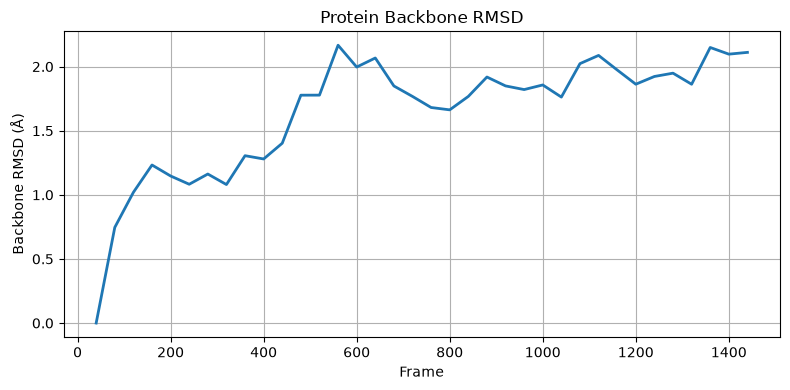

In [22]:
#protein RMSD
R = rms.RMSD(
    u,
    u,
    select="protein and backbone"
)

R.run()

rmsd = R.results.rmsd

plt.figure(figsize=(8,4))
plt.plot(rmsd[:,1], rmsd[:,2], lw=2)
plt.xlabel("Frame")
plt.ylabel("Backbone RMSD (Å)")
plt.title("Protein Backbone RMSD")
plt.grid(True)
plt.tight_layout()
plt.show()

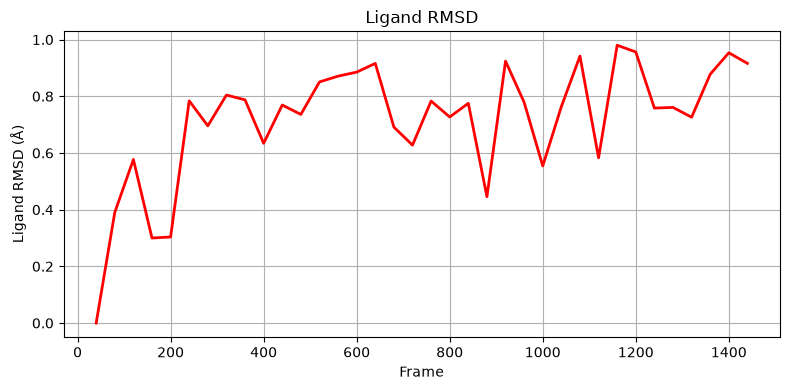

In [23]:
#Ligand RMSD
R = rms.RMSD(
    u,
    u,
    select="resname UNL"
)

R.run()

lig_rmsd = R.results.rmsd

plt.figure(figsize=(8,4))
plt.plot(lig_rmsd[:,1], lig_rmsd[:,2], color="red", lw=2)
plt.xlabel("Frame")
plt.ylabel("Ligand RMSD (Å)")
plt.title("Ligand RMSD")
plt.grid(True)
plt.tight_layout()
plt.show()

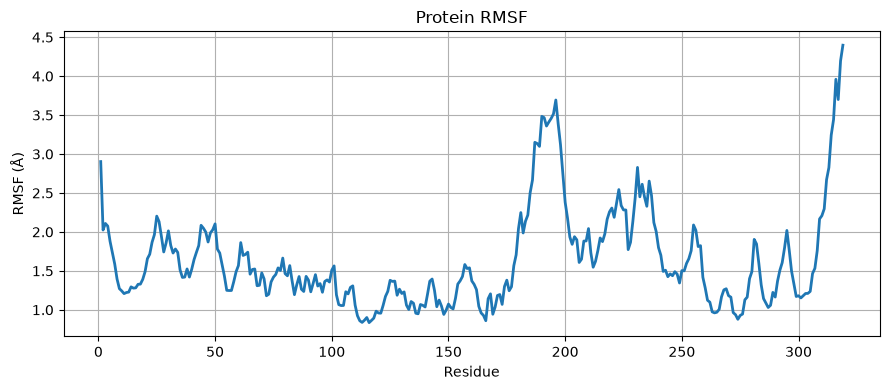

In [24]:
#RMSF
protein = u.select_atoms("protein and name CA")

R = rms.RMSF(protein)
R.run()

plt.figure(figsize=(9,4))
plt.plot(protein.resids, R.results.rmsf, lw=2)

plt.xlabel("Residue")
plt.ylabel("RMSF (Å)")
plt.title("Protein RMSF")
plt.grid(True)
plt.tight_layout()
plt.show()

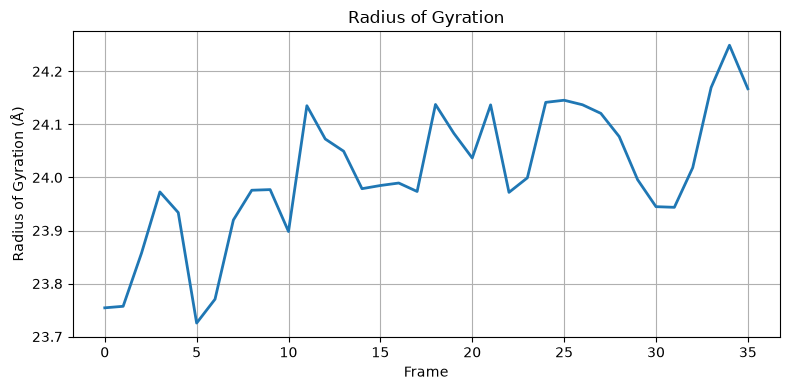

In [25]:
#Radius of Gyration
protein = u.select_atoms("protein")

Rg = []

for ts in u.trajectory:
    Rg.append(protein.radius_of_gyration())

plt.figure(figsize=(8,4))
plt.plot(Rg, lw=2)

plt.xlabel("Frame")
plt.ylabel("Radius of Gyration (Å)")
plt.title("Radius of Gyration")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
#Distance between ligand and a residue

lig = u.select_atoms("resname UNL")
cys = u.select_atoms("resid 111 and name SG")

dist = []

for ts in u.trajectory:

    d = np.linalg.norm(
        lig.center_of_mass() -
        cys.positions[0]
    )

    dist.append(d)

plt.figure(figsize=(8,4))
plt.plot(dist, lw=2)

plt.xlabel("Frame")
plt.ylabel("Distance (Å)")
plt.title("Ligand–Cys111 Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

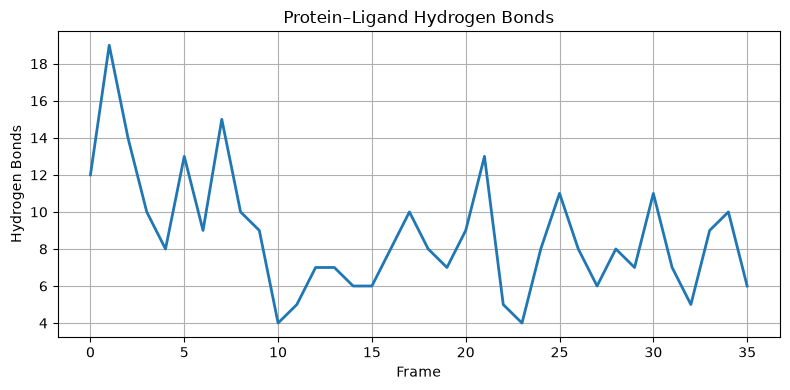

In [29]:
#Number of protein-ligand hydrogen bonds
hb = HydrogenBondAnalysis(
    universe=u,
    donors_sel="protein or resname UNL",
    hydrogens_sel="name H*",
    acceptors_sel="protein or resname UNL",
    between=["protein", "resname UNL"]
)

hb.run()

hbonds = hb.results.hbonds

frames = hbonds[:,0]

unique, counts = np.unique(frames, return_counts=True)

plt.figure(figsize=(8,4))
plt.plot(unique, counts, lw=2)

plt.xlabel("Frame")
plt.ylabel("Hydrogen Bonds")
plt.title("Protein–Ligand Hydrogen Bonds")
plt.grid(True)
plt.tight_layout()
plt.show()

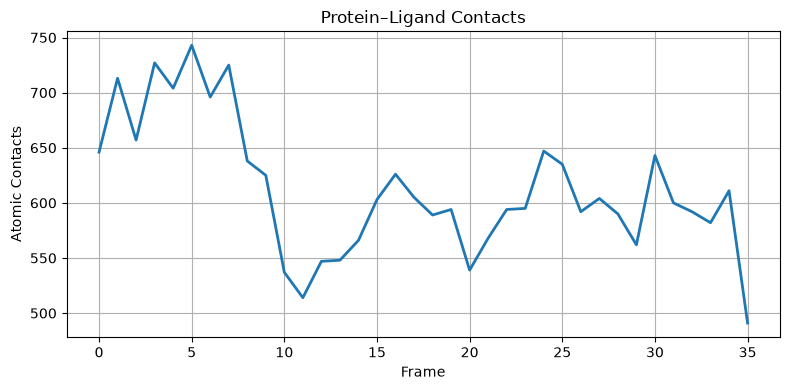

In [31]:
#Number of Protein–Ligand Contacts (<4.5 Å)
protein = u.select_atoms("protein")
ligand = u.select_atoms("resname UNL")

contacts = []

for ts in u.trajectory:

    d = np.linalg.norm(
        protein.positions[:,None,:] -
        ligand.positions[None,:,:],
        axis=2
    )

    contacts.append(np.sum(d < 4.5))

plt.figure(figsize=(8,4))
plt.plot(contacts, lw=2)

plt.xlabel("Frame")
plt.ylabel("Atomic Contacts")
plt.title("Protein–Ligand Contacts")
plt.grid(True)
plt.tight_layout()
plt.show()

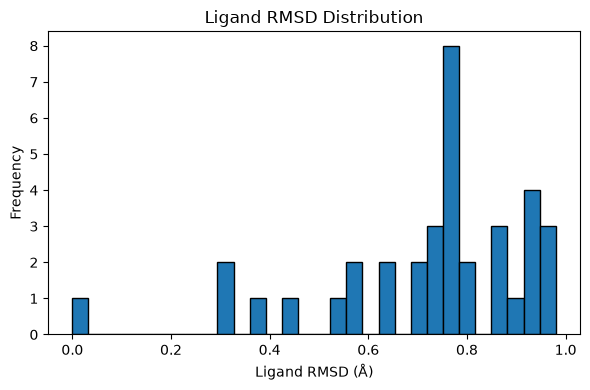

In [32]:
#Histogram of Ligand RMSD
plt.figure(figsize=(6,4))

plt.hist(lig_rmsd[:,2],
         bins=30,
         edgecolor='black')

plt.xlabel("Ligand RMSD (Å)")
plt.ylabel("Frequency")
plt.title("Ligand RMSD Distribution")

plt.tight_layout()
plt.show()

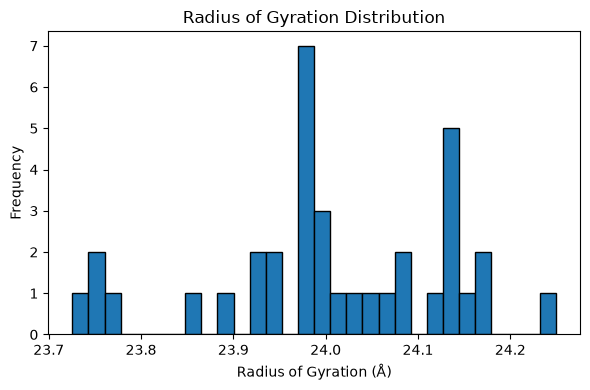

In [33]:
#9. Histogram of Radius of Gyration
plt.figure(figsize=(6,4))

plt.hist(Rg,
         bins=30,
         edgecolor='black')

plt.xlabel("Radius of Gyration (Å)")
plt.ylabel("Frequency")
plt.title("Radius of Gyration Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Save all plots
plt.savefig("backbone_rmsd.png", dpi=300, bbox_inches="tight")
plt.show()